# Limpieza del Dataset

## Importaciones 

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA; pca = PCA(n_components=2)
from sklearn.cluster import KMeans; kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Configuración para que los gráficos se vean mejor
%matplotlib inline
sns.set_theme(style="whitegrid")

print("Librerías listas para la limpieza.")

Librerías listas para la limpieza.


## Carga del Dataset

In [3]:
# Configuración para ver todas las columnas en el notebook
pd.set_option('display.max_columns', None)

## Radiogradia Inicial

In [4]:
df = pd.read_csv('../data/raw/Internship_Selection_Dataset.csv')
df_data_raw = df.copy()
df

,student_id,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,extracurricular,college_tier,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,placement_training,selected
0,1,6.87,7,0,0,4,3,2,7,Yes,Tier 2,0,7,5,9,3,1,4,4,Yes,1
1,2,9.75,4,4,2,3,3,6,1,Yes,Tier 2,3,2,8,8,3,9,8,5,Yes,1
2,3,8.66,2,1,1,2,1,4,6,Yes,Tier 2,4,1,5,2,2,1,3,2,Yes,1
3,4,7.99,5,4,2,8,8,10,8,No,Tier 2,1,5,5,9,2,7,10,1,Yes,1
4,5,5.78,3,2,2,4,9,1,7,Yes,Tier 3,4,7,3,8,7,8,6,5,Yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,9.29,8,3,1,10,2,4,6,No,Tier 2,4,5,10,2,6,5,3,4,No,0
9996,9997,9.49,4,2,1,7,1,3,5,Yes,Tier 1,2,8,6,10,1,5,1,1,Yes,0
9997,9998,9.73,8,0,0,1,4,4,9,Yes,Tier 2,3,6,4,5,9,10,2,3,No,1
9998,9999,6.99,5,1,1,3,6,9,5,No,Tier 2,2,2,10,2,4,8,1,4,No,1


In [ ]:
# Se realiza un análisis técnico , "data quality check" para analizar el dataset de forma automática y entender su calidad

# Función 1 :radiografía técnica
def radiografia_tecnica(df):
    print("="*60)
    print(f"{' RADIOGRAFÍA DEL DATASET -#SNAPSHOT-':^60}")
    print("="*60)

    # 1. Dimensiones básicas
    filas, columnas = df.shape
    nulos_totales = df.isnull().sum().sum()
    duplicados = df.duplicated().sum()
    memoria = df.memory_usage(deep=True).sum() / (1024**2) # En MB

    print(f"  • Filas: {filas:,}")
    print(f"  • Columnas: {columnas}")
    print(f"  • Celdas totales: {df.size:,}")
    print(f"  • Datos faltantes: {nulos_totales:,} ({ (nulos_totales/df.size)*100:.2f}%)" if df.size > 0 else "  • Datos faltantes: 0")
    print(f"  • Filas duplicadas: {duplicados}")
    print(f"  • Uso de memoria: {memoria:.2f} MB")
    print("-" * 60)

    # 2. Análisis detallado por columna
    resumen_cols = pd.DataFrame({
        'Tipo': df.dtypes,
        'No Nulos': df.count(),
        'Nulos': df.isnull().sum(),
        '% Nulos': (df.isnull().sum() / filas) * 100,
        'Unicos': df.nunique(),
        'Cardinalidad (%)': (df.nunique() / filas) * 100
    })

    # Ejemplo de datos
    resumen_cols['Ejemplo'] = [df[col].dropna().iloc[0] if not df[col].dropna().empty else "N/A" for col in df.columns]

    display(resumen_cols.style.format({'% Nulos': '{:.2f}%', 'Cardinalidad (%)': '{:.2f}%'}) \
        .background_gradient(cmap='Reds', subset=['% Nulos']) \
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]},
                           {'selector': 'td', 'props': [('text-align', 'left')]}]))

    print("-" * 60)
    print(f"{' ESTADÍSTICAS NUMÉRICAS ':^60}")
    display(df.describe().T)

    print("-" * 60)
    print(f"{' DISTRIBUCIÓN DE NULOS (VISUAL) ':^60}")
    msno.matrix(df, figsize=(10,4), fontsize=9)
    plt.show()


# Función 2: El plan de acción (Resumen adaptado)
def plan_accion_datos(df):
    print("\n" + "="*60)
    print(f"{' 🚀 RESUMEN: PLAN DE ACCIÓN RECOMENDADO ':^60}")
    print("="*60)

    # Duplicados
    duplicados = df.duplicated().sum()
    if duplicados > 0:
        print(f"  [ ] DUPLICADOS: Eliminar {duplicados} filas repetidas.")

    # Nulos
    nulos_criticos = df.columns[df.isnull().sum() / len(df) > 0.3].tolist()
    if nulos_criticos:
        print(f"  [ ] NULOS: Revisar columnas con >30% de vacío: {nulos_criticos}")

    # Montos (amount)
    if 'amount' in df.columns:
        anomalos = (df['amount'] < 0).sum()
        if anomalos > 0:
            print(f"  [ ] VALORES: Revisar {anomalos} registros con 'amount' negativo.")

    # Fechas (Específicas de tu tabla: rental_date, return_date)
    cols_fecha = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]
    cols_a_convertir = [col for col in cols_fecha if not pd.api.types.is_datetime64_any_dtype(df[col])]

    if cols_a_convertir:
        print(f"  [ ] FORMATO: Convertir a datetime: {cols_a_convertir}")

    print("-" * 60)
    print("  TIP: Los campos de fecha actuales son 'object'. Cámbialos para análisis temporal.")
    print("="*60)

# Función 3: Comparativo Snapshot (Sin cambios, es universal)
def comparativo_snapshot(df_inicial, df_final):
    print("="*60)
    print(f"{' ⚖️ COMPARATIVA DE CALIDAD DE DATOS ':^60}")
    print("="*60)

    def get_metrics(df):
        return [
            f"{len(df):,}",
            df.shape[1],
            f"{df.isnull().sum().sum():,}",
            f"{(df.isnull().sum().sum() / df.size * 100 if df.size > 0 else 0):.2f}%",
            df.duplicated().sum(),
            f"{df.memory_usage(deep=True).sum() / (1024**2):.2f}"
        ]

    metrics = {
        'Métrica': ['Filas Totales', 'Columnas', 'Celdas con Nulos', '% Global de Nulos', 'Filas Duplicadas', 'Memoria (MB)'],
        'Snapshot Inicial': get_metrics(df_inicial),
        'Snapshot Final': get_metrics(df_final)
    }

    comparativa_df = pd.DataFrame(metrics)

    display(comparativa_df.style.set_properties(**{'text-align': 'center'})
            .set_table_styles([{'selector': 'th', 'props': [('background-color', '#f0f2f6')]}])
            .hide(axis='index'))

    eliminadas = len(df_inicial) - len(df_final)
    print(f"\n✅ Se han depurado {eliminadas:,} filas en total.")
    print("="*60)

             RADIOGRAFÍA DEL DATASET -#SNAPSHOT-            
  • Filas: 10,000
  • Columnas: 21
  • Celdas totales: 210,000
  • Datos faltantes: 0 (0.00%)
  • Filas duplicadas: 0
  • Uso de memoria: 2.88 MB
------------------------------------------------------------


,Tipo,No Nulos,Nulos,% Nulos,Unicos,Cardinalidad (%),Ejemplo
student_id,int64,10000,0,0.00%,10000,100.00%,1
CGPA,float64,10000,0,0.00%,501,5.01%,6.870000
skills_score,int64,10000,0,0.00%,10,0.10%,7
projects_count,int64,10000,0,0.00%,6,0.06%,0
internships_done,int64,10000,0,0.00%,4,0.04%,0
communication_score,int64,10000,0,0.00%,10,0.10%,4
aptitude_score,int64,10000,0,0.00%,10,0.10%,3
coding_test_score,int64,10000,0,0.00%,10,0.10%,2
resume_score,int64,10000,0,0.00%,10,0.10%,7
extracurricular,str,10000,0,0.00%,2,0.02%,Yes


------------------------------------------------------------
                   ESTADÍSTICAS NUMÉRICAS                   


,count,mean,std,min,25%,50%,75%,max
student_id,10000.0,5000.500000,2886.895680,1.0,2500.75,5000.50,7500.25,10000.0
CGPA,10000.0,7.470792,1.438135,5.0,6.23,7.46,8.70,10.0
skills_score,10000.0,5.480200,2.884829,1.0,3.00,5.00,8.00,10.0
projects_count,10000.0,2.534300,1.690713,0.0,1.00,3.00,4.00,5.0
internships_done,10000.0,1.502000,1.115043,0.0,1.00,2.00,2.00,3.0
communication_score,10000.0,5.562800,2.864765,1.0,3.00,6.00,8.00,10.0
aptitude_score,10000.0,5.526600,2.861627,1.0,3.00,6.00,8.00,10.0
coding_test_score,10000.0,5.449400,2.865320,1.0,3.00,5.00,8.00,10.0
resume_score,10000.0,5.572200,2.875868,1.0,3.00,6.00,8.00,10.0
hackathons_participated,10000.0,2.520500,1.699079,0.0,1.00,3.00,4.00,5.0


------------------------------------------------------------
               DISTRIBUCIÓN DE NULOS (VISUAL)               


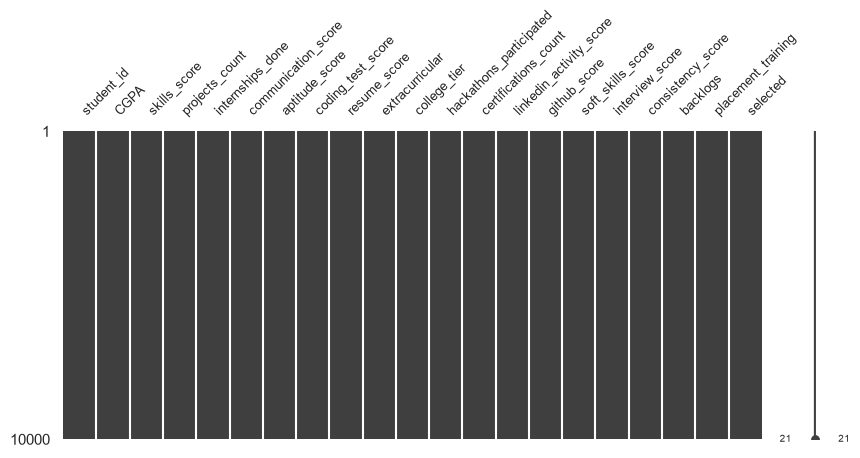


           🚀 RESUMEN: PLAN DE ACCIÓN RECOMENDADO            
------------------------------------------------------------
  TIP: Los campos de fecha actuales son 'object'. Cámbialos para análisis temporal.


In [9]:
# Para ver el estado actual de tus 15,861 filas:
radiografia_tecnica(df)

# Para ver qué deberías limpiar:
plan_accion_datos(df)

## Limpieza de datos

### Comprobacion de nulos

In [10]:
df.isnull().sum()

student_id                 0
CGPA                       0
skills_score               0
projects_count             0
internships_done           0
communication_score        0
aptitude_score             0
coding_test_score          0
resume_score               0
extracurricular            0
college_tier               0
hackathons_participated    0
certifications_count       0
linkedin_activity_score    0
github_score               0
soft_skills_score          0
interview_score            0
consistency_score          0
backlogs                   0
placement_training         0
selected                   0
dtype: int64

No hay valores nulos.

Acto seguido utilizamos info para comprobar cómo está construida la base de datos por detrás diciendonos el tipo de datos 

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               10000 non-null  int64  
 1   CGPA                     10000 non-null  float64
 2   skills_score             10000 non-null  int64  
 3   projects_count           10000 non-null  int64  
 4   internships_done         10000 non-null  int64  
 5   communication_score      10000 non-null  int64  
 6   aptitude_score           10000 non-null  int64  
 7   coding_test_score        10000 non-null  int64  
 8   resume_score             10000 non-null  int64  
 9   extracurricular          10000 non-null  str    
 10  college_tier             10000 non-null  str    
 11  hackathons_participated  10000 non-null  int64  
 12  certifications_count     10000 non-null  int64  
 13  linkedin_activity_score  10000 non-null  int64  
 14  github_score             10000 non

In [12]:
df.head(20)

,student_id,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,extracurricular,college_tier,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,placement_training,selected
0,1,6.87,7,0,0,4,3,2,7,Yes,Tier 2,0,7,5,9,3,1,4,4,Yes,1
1,2,9.75,4,4,2,3,3,6,1,Yes,Tier 2,3,2,8,8,3,9,8,5,Yes,1
2,3,8.66,2,1,1,2,1,4,6,Yes,Tier 2,4,1,5,2,2,1,3,2,Yes,1
3,4,7.99,5,4,2,8,8,10,8,No,Tier 2,1,5,5,9,2,7,10,1,Yes,1
4,5,5.78,3,2,2,4,9,1,7,Yes,Tier 3,4,7,3,8,7,8,6,5,Yes,1
5,6,5.78,9,5,1,2,5,1,5,No,Tier 3,2,9,4,8,3,7,4,4,No,0
6,7,5.29,6,3,1,9,1,2,4,Yes,Tier 1,4,7,9,1,10,2,2,5,Yes,1
7,8,9.33,1,2,0,8,1,4,2,Yes,Tier 3,2,5,9,2,3,6,1,2,No,0
8,9,8.01,3,5,2,5,9,8,1,No,Tier 1,0,5,3,3,6,8,9,4,No,0
9,10,8.54,4,0,1,8,1,3,1,No,Tier 1,4,5,5,8,2,8,4,4,Yes,1


In [15]:
df['college_tier'] = df['college_tier'].str.replace(' ', '', regex=False)

In [16]:
df.head(20)

,student_id,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,extracurricular,college_tier,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,placement_training,selected
0,1,6.87,7,0,0,4,3,2,7,Yes,Tier2,0,7,5,9,3,1,4,4,Yes,1
1,2,9.75,4,4,2,3,3,6,1,Yes,Tier2,3,2,8,8,3,9,8,5,Yes,1
2,3,8.66,2,1,1,2,1,4,6,Yes,Tier2,4,1,5,2,2,1,3,2,Yes,1
3,4,7.99,5,4,2,8,8,10,8,No,Tier2,1,5,5,9,2,7,10,1,Yes,1
4,5,5.78,3,2,2,4,9,1,7,Yes,Tier3,4,7,3,8,7,8,6,5,Yes,1
5,6,5.78,9,5,1,2,5,1,5,No,Tier3,2,9,4,8,3,7,4,4,No,0
6,7,5.29,6,3,1,9,1,2,4,Yes,Tier1,4,7,9,1,10,2,2,5,Yes,1
7,8,9.33,1,2,0,8,1,4,2,Yes,Tier3,2,5,9,2,3,6,1,2,No,0
8,9,8.01,3,5,2,5,9,8,1,No,Tier1,0,5,3,3,6,8,9,4,No,0
9,10,8.54,4,0,1,8,1,3,1,No,Tier1,4,5,5,8,2,8,4,4,Yes,1


### Comprobación de duplicados

In [17]:
df.duplicated().sum()

np.int64(0)

No hay datos duplicados.

In [18]:
df.dtypes

student_id                   int64
CGPA                       float64
skills_score                 int64
projects_count               int64
internships_done             int64
communication_score          int64
aptitude_score               int64
coding_test_score            int64
resume_score                 int64
extracurricular                str
college_tier                   str
hackathons_participated      int64
certifications_count         int64
linkedin_activity_score      int64
github_score                 int64
soft_skills_score            int64
interview_score              int64
consistency_score            int64
backlogs                     int64
placement_training             str
selected                     int64
dtype: object

In [20]:
df.info()
df.head()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               10000 non-null  int64  
 1   CGPA                     10000 non-null  float64
 2   skills_score             10000 non-null  int64  
 3   projects_count           10000 non-null  int64  
 4   internships_done         10000 non-null  int64  
 5   communication_score      10000 non-null  int64  
 6   aptitude_score           10000 non-null  int64  
 7   coding_test_score        10000 non-null  int64  
 8   resume_score             10000 non-null  int64  
 9   extracurricular          10000 non-null  str    
 10  college_tier             10000 non-null  str    
 11  hackathons_participated  10000 non-null  int64  
 12  certifications_count     10000 non-null  int64  
 13  linkedin_activity_score  10000 non-null  int64  
 14  github_score             10000 non

Index(['student_id', 'CGPA', 'skills_score', 'projects_count',
       'internships_done', 'communication_score', 'aptitude_score',
       'coding_test_score', 'resume_score', 'extracurricular', 'college_tier',
       'hackathons_participated', 'certifications_count',
       'linkedin_activity_score', 'github_score', 'soft_skills_score',
       'interview_score', 'consistency_score', 'backlogs',
       'placement_training', 'selected'],
      dtype='str')

In [21]:
#Comparativa
comparativo_snapshot(df_data_raw, df)

             ⚖️ COMPARATIVA DE CALIDAD DE DATOS             


Métrica,Snapshot Inicial,Snapshot Final
Filas Totales,"10,000","10,000"
Columnas,21,21
Celdas con Nulos,0,0
% Global de Nulos,0.00%,0.00%
Filas Duplicadas,0,0
Memoria (MB),2.88,2.87



✅ Se han depurado 0 filas en total.


No hay un cambio significativo porque los datos en este dataset estaban bastante limpios y bien tratados.